# Análisis de series de tiempo: PIB mundial (1960 - 2022)

**Alumno:** Edward González Magdaleno

---

## Objetivo

Analizar el comportamiento del Producto Interno Bruto (PIB) de los países del mundo
para identificar patrones a nivel histórico, por región geográfica y por nivel de ingreso.

## Fases

1. Lectura y exploración inicial del set de datos
2. Planteamiento del análisis exploratorio
3. Preprocesamiento y preparación de las series de tiempo
4. Análisis exploratorio
5. Conclusión

## ¿Qué es el PIB?

Es el monto total, en dólares corrientes, de todos los bienes y servicios finales que
un país genera durante un año. Al estar en **dólares corrientes** (current US$) el monto
incluye el efecto de la inflación y del tipo de cambio, algo que hay que tener presente
al interpretar los resultados.

In [10]:
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13

ANIO_INICIO = 1960
ANIO_FIN = 2022

In [9]:
ruta_datos = glob.glob("API_NY.GDP*.csv")[0]
ruta_meta = glob.glob("Metadata_Country*.csv")[0]

In [11]:
# Lectura de los archivos
gdp_raw = pd.read_csv(ruta_datos, skiprows=4)
meta_raw = pd.read_csv(ruta_meta)

print(f"Tabla de PIB       : {gdp_raw.shape[0]} filas x {gdp_raw.shape[1]} columnas")
print(f"Tabla de metadatos : {meta_raw.shape[0]} filas x {meta_raw.shape[1]} columnas")

Tabla de PIB       : 265 filas x 71 columnas
Tabla de metadatos : 264 filas x 6 columnas


In [12]:
gdp_raw[["Country Name", "Country Code", "Indicator Name", "1960", "1990", "2022"]].head(10)

,Country Name,Country Code,Indicator Name,1960,1990,2022
0,Aruba,ABW,GDP (current US$),NaN,7.648045e+08,3.326671e+09
1,Africa Eastern and Southern,AFE,GDP (current US$),2.420573e+10,2.563835e+11,1.226461e+12
2,Afghanistan,AFG,GDP (current US$),NaN,NaN,1.449724e+10
3,Africa Western and Central,AFW,GDP (current US$),1.190481e+10,1.242778e+11,1.063748e+12
4,Angola,AGO,GDP (current US$),NaN,1.122952e+10,1.282340e+11
5,Albania,ALB,GDP (current US$),NaN,2.028554e+09,1.901725e+10
6,Andorra,AND,GDP (current US$),NaN,1.028990e+09,3.380613e+09
7,Arab World,ARB,GDP (current US$),NaN,6.416840e+11,3.752345e+12
8,United Arab Emirates,ARE,GDP (current US$),NaN,5.070137e+10,5.114034e+11
9,Argentina,ARG,GDP (current US$),1.586547e+10,1.413527e+11,6.339938e+11


In [ ]:
# Estructura general de la tabla
print("Primeras columnas:", gdp_raw.columns[:6].tolist())
print("Últimas columnas :", gdp_raw.columns[-5:].tolist())
print()
print("Indicador contenido:", gdp_raw["Indicator Name"].unique())
print("Código del indicador:", gdp_raw["Indicator Code"].unique())

In [13]:
meta_raw.head(10)

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN
5,ALB,Europe & Central Asia,Upper middle income,NaN,Albania,NaN
6,AND,Europe & Central Asia,High income,NaN,Andorra,NaN
7,ARB,NaN,NaN,Arab World aggregate. Arab World is composed o...,Arab World,NaN
8,ARE,Middle East & North Africa,High income,NaN,United Arab Emirates,NaN
9,ARG,Latin America & Caribbean,Upper middle income,Due to the limitations of the Atlas method in ...,Argentina,NaN


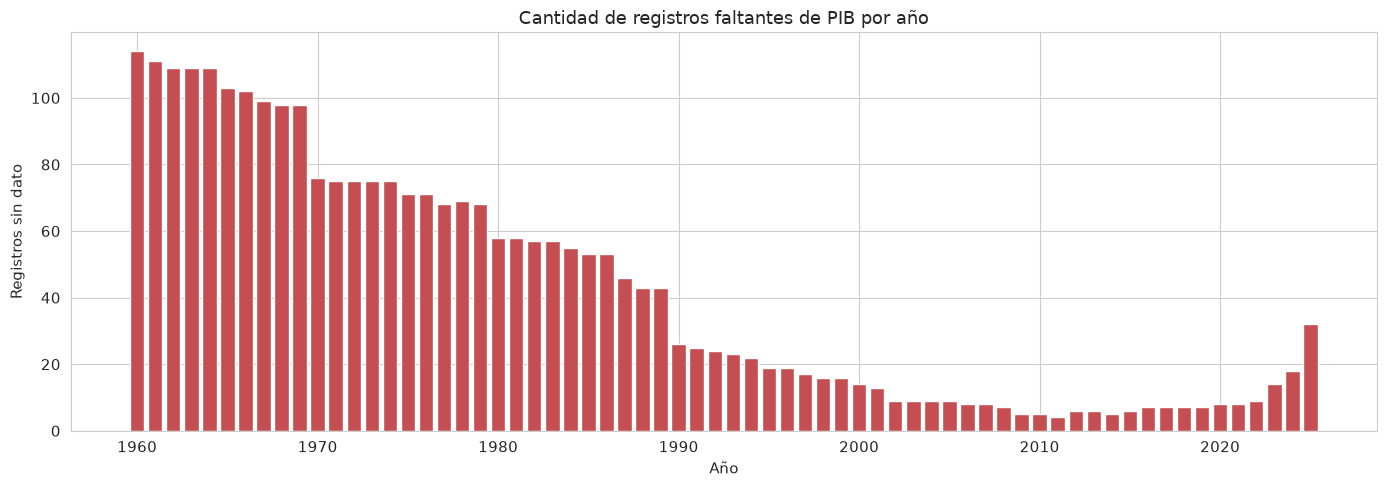

Año con más faltantes: 1960 -> 114 registros
Año con menos faltantes: 2011 -> 4 registros


In [14]:
# Exploración de valores faltantes

anios_todos = [c for c in gdp_raw.columns if c.isdigit()]

nulos_por_anio = gdp_raw[anios_todos].isna().sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(nulos_por_anio.index.astype(int), nulos_por_anio.values, color="#c44e52")
ax.set_title("Cantidad de registros faltantes de PIB por año")
ax.set_xlabel("Año")
ax.set_ylabel("Registros sin dato")
plt.tight_layout()
plt.show()

print("Año con más faltantes:", nulos_por_anio.idxmax(), "->", nulos_por_anio.max(), "registros")
print("Año con menos faltantes:", nulos_por_anio.idxmin(), "->", nulos_por_anio.min(), "registros")

Los años más antiguos (décadas de 1960 y 1970) tienen muchos más faltantes: varios países
todavía no existían como tales o no reportaban sus cuentas nacionales al Banco Mundial.
Hacia el final de la serie los faltantes casi desaparecen. Esto condiciona el análisis:
**si sumamos el PIB de todos los países por año, los años antiguos quedarán subestimados**.

In [15]:
# tienen la columna Region vacía.
agregados = meta_raw[meta_raw["Region"].isna()]

print(f"Filas totales en metadatos : {len(meta_raw)}")
print(f"Agregados (Region vacía)   : {len(agregados)}")
print(f"Países reales              : {len(meta_raw) - len(agregados)}")
print("\nEjemplos de agregados:")
print(agregados["TableName"].head(15).to_string(index=False))

Filas totales en metadatos : 264
Agregados (Region vacía)   : 47
Países reales              : 217

Ejemplos de agregados:
                  Africa Eastern and Southern
                   Africa Western and Central
                                   Arab World
               Central Europe and the Baltics
                       Caribbean small states
  East Asia & Pacific (excluding high income)
                   Early-demographic dividend
                          East Asia & Pacific
Europe & Central Asia (excluding high income)
                        Europe & Central Asia
                                    Euro area
                               European Union
                                  High income
       Heavily indebted poor countries (HIPC)
                                    IBRD only



# 2. Planteamiento del análisis exploratorio


| # | Pregunta |
|---|---|
| P1 | ¿Cómo ha evolucionado el PIB mundial entre 1960 y 2022? ¿Hay tendencia? |
| P2 | ¿Cuáles son las economías más grandes y cómo cambió el ranking con el tiempo? |
| P3 | ¿Cómo se distribuye el PIB entre las regiones del mundo? |
| P4 | ¿Qué peso tiene cada nivel de ingreso y cómo cambió? |
| P5 | ¿Se alcanzan a ver las crisis económicas en las series? |
| P6 | ¿La serie del PIB es **estacionaria**? Si no, ¿cómo la volvemos estacionaria? |

---
# 3. Preprocesamiento y preparación de las series de tiempo

In [16]:

# Limpieza de la tabla principal

gdp = gdp_raw.copy()

# a) Eliminar columnas que no aportan información
gdp = gdp.drop(columns=["Indicator Name", "Indicator Code"])
gdp = gdp.loc[:, ~gdp.columns.str.startswith("Unnamed")]

# b) Recortar el periodo de análisis (1960 - 2022)
anios = [str(a) for a in range(ANIO_INICIO, ANIO_FIN + 1)]
gdp = gdp[["Country Name", "Country Code"] + anios]

print(f"Después de limpiar: {gdp.shape[0]} filas x {gdp.shape[1]} columnas")
gdp.head()

Después de limpiar: 265 filas x 65 columnas


,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.727849e+09,2.790850e+09,2.962907e+09,2.983637e+09,3.092428e+09,3.276188e+09,3.347562e+09,2.461056e+09,2.889305e+09,3.326671e+09
1,Africa Eastern and Southern,AFE,2.420573e+10,2.495893e+10,2.707328e+10,3.176919e+10,3.027960e+10,3.380623e+10,3.692731e+10,3.844423e+10,...,9.812032e+11,9.987272e+11,9.099053e+11,8.326614e+11,9.792406e+11,1.021972e+12,1.019354e+12,9.385461e+11,1.113060e+12,1.226461e+12
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.014642e+10,2.049713e+10,1.913422e+10,1.811657e+10,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10
3,Africa Western and Central,AFW,1.190481e+10,1.270772e+10,1.363059e+10,1.446891e+10,1.580356e+10,1.692088e+10,1.803395e+10,1.649354e+10,...,8.441880e+11,9.040949e+11,7.780375e+11,6.999795e+11,6.942064e+11,7.778058e+11,1.026528e+12,9.636882e+11,1.026670e+12,1.063748e+12
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.488452e+11,1.534499e+11,1.025431e+11,6.077005e+10,8.562960e+10,9.050606e+10,8.119381e+10,5.851203e+10,7.828392e+10,1.282340e+11


In [17]:
# Limpieza de metadatos y unión de ambas tablas

meta = meta_raw[["Country Code", "Region", "IncomeGroup"]].copy()

# Se une por Country Code, que es la llave común entre ambas tablas
gdp = gdp.merge(meta, on="Country Code", how="left")

print("Columnas después del merge:", gdp.columns[:2].tolist(), "+ años +",
      gdp.columns[-2:].tolist())
gdp[["Country Name", "Country Code", "Region", "IncomeGroup", "2022"]].head()

Columnas después del merge: ['Country Name', 'Country Code'] + años + ['Region', 'IncomeGroup']


,Country Name,Country Code,Region,IncomeGroup,2022
0,Aruba,ABW,Latin America & Caribbean,High income,3.326671e+09
1,Africa Eastern and Southern,AFE,NaN,NaN,1.226461e+12
2,Afghanistan,AFG,Middle East & North Africa,Low income,1.449724e+10
3,Africa Western and Central,AFW,NaN,NaN,1.063748e+12
4,Angola,AGO,Sub-Saharan Africa,Lower middle income,1.282340e+11


In [18]:
# Separación de países reales y agregados

paises = gdp[gdp["Region"].notna()].reset_index(drop=True)
grupos = gdp[gdp["Region"].isna()].reset_index(drop=True)

print(f"Países reales : {len(paises)}")
print(f"Agregados     : {len(grupos)}")

sin_metadata = set(gdp["Country Code"]) - set(meta_raw["Country Code"])
print(f"\nCódigos sin metadatos: {sin_metadata}")
print(gdp[gdp["Country Code"].isin(sin_metadata)]["Country Name"].tolist())

serie_mundo = grupos[grupos["Country Code"] == "WLD"][anios].iloc[0]
serie_mundo.index = pd.to_datetime(serie_mundo.index, format="%Y")
serie_mundo = serie_mundo.astype(float)
serie_mundo.name = "PIB mundial"

print("\nSerie mundial lista:", serie_mundo.shape[0], "observaciones anuales")

Países reales : 217
Agregados     : 48

Códigos sin metadatos: {'INX'}
['Not classified']

Serie mundial lista: 63 observaciones anuales


In [19]:
# agrupar por región y nivel de ingreso

df_largo = paises.melt(
    id_vars=["Country Name", "Country Code", "Region", "IncomeGroup"],
    value_vars=anios,
    var_name="Anio",
    value_name="PIB",
)
df_largo["Anio"] = df_largo["Anio"].astype(int)

print(f"Formato largo: {df_largo.shape[0]} filas (países x años)")
df_largo.head()

Formato largo: 13671 filas (países x años)


,Country Name,Country Code,Region,IncomeGroup,Anio,PIB
0,Aruba,ABW,Latin America & Caribbean,High income,1960,NaN
1,Afghanistan,AFG,Middle East & North Africa,Low income,1960,NaN
2,Angola,AGO,Sub-Saharan Africa,Lower middle income,1960,NaN
3,Albania,ALB,Europe & Central Asia,Upper middle income,1960,NaN
4,Andorra,AND,Europe & Central Asia,High income,1960,NaN


In [20]:
# Se transpone para que cada columna sea un país y el índice sea el año
df_ts = paises.set_index("Country Name")[anios].T
df_ts.index = pd.to_datetime(df_ts.index, format="%Y")
df_ts.index.name = "Anio"
df_ts = df_ts.astype(float)

print(f"Matriz de series de tiempo: {df_ts.shape[0]} años x {df_ts.shape[1]} países")
df_ts.iloc[-5:, :5]

Matriz de series de tiempo: 63 años x 217 países


Country Name,Aruba,Afghanistan,Angola,Albania,Andorra
Anio,,,,,
2018-01-01,3.276188e+09,1.805322e+10,9.050606e+10,1.537951e+10,3.218420e+09
2019-01-01,3.347562e+09,1.879944e+10,8.119381e+10,1.558511e+10,3.155149e+09
2020-01-01,2.461056e+09,1.995593e+10,5.851203e+10,1.524146e+10,2.891001e+09
2021-01-01,2.889305e+09,1.426000e+10,7.828392e+10,1.803199e+10,3.324648e+09
2022-01-01,3.326671e+09,1.449724e+10,1.282340e+11,1.901725e+10,3.380613e+09


In [21]:
completitud = df_ts.notna().mean().sort_values(ascending=False) * 100

print("Países con serie completa (63 años):", (completitud == 100).sum())
print("Países con menos del 50% de datos  :", (completitud < 50).sum())
print("\nPaíses con series más incompletas:")
print(completitud.tail(8).round(1).to_string())

Países con serie completa (63 años): 111
Países con menos del 50% de datos  : 25

Países con series más incompletas:
Country Name
Cayman Islands               27.0
Kosovo                       23.8
Sint Maarten (Dutch part)    22.2
South Sudan                  12.7
St. Martin (French part)      6.3
Gibraltar                     0.0
Korea, Dem. People's Rep.     0.0
British Virgin Islands        0.0


---
# 4. Análisis exploratorio

In [22]:
# Función


def formato_billones(x, pos):
    return f"{x / 1e12:.0f}"


def eje_billones(ax, etiqueta="PIB (billones de USD corrientes)"):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_billones))
    ax.set_ylabel(etiqueta)

## P1. Evolución del PIB mundial

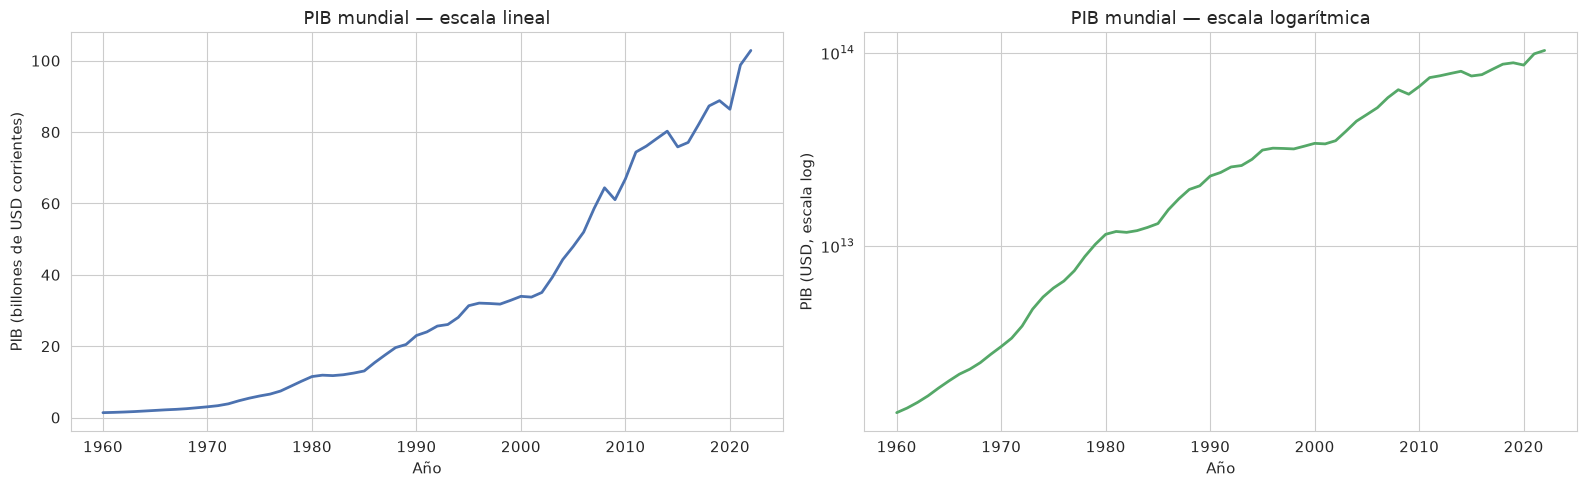

PIB mundial 1960 : 1.37 billones USD
PIB mundial 2022 : 102.86 billones USD
Crecimiento total: x75.2


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Escala lineal
axes[0].plot(serie_mundo.index, serie_mundo.values, linewidth=2, color="#4c72b0")
axes[0].set_title("PIB mundial — escala lineal")
axes[0].set_xlabel("Año")
eje_billones(axes[0])

# Escala logarítmica
axes[1].plot(serie_mundo.index, serie_mundo.values, linewidth=2, color="#55a868")
axes[1].set_yscale("log")
axes[1].set_title("PIB mundial — escala logarítmica")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("PIB (USD, escala log)")

plt.tight_layout()
plt.show()

print(f"PIB mundial 1960 : {serie_mundo.iloc[0] / 1e12:,.2f} billones USD")
print(f"PIB mundial 2022 : {serie_mundo.iloc[-1] / 1e12:,.2f} billones USD")
print(f"Crecimiento total: x{serie_mundo.iloc[-1] / serie_mundo.iloc[0]:,.1f}")

La escala lineal muestra una **curva exponencial**: la serie tiene una tendencia creciente y
además su variabilidad crece con el nivel (heterocedasticidad).

En escala logarítmica la misma serie se ve casi como una **línea recta**, lo que confirma que
el crecimiento es aproximadamente **multiplicativo** (un porcentaje más o menos constante cada año).
Este es justo el caso donde aplicar logaritmo estabiliza la varianza.

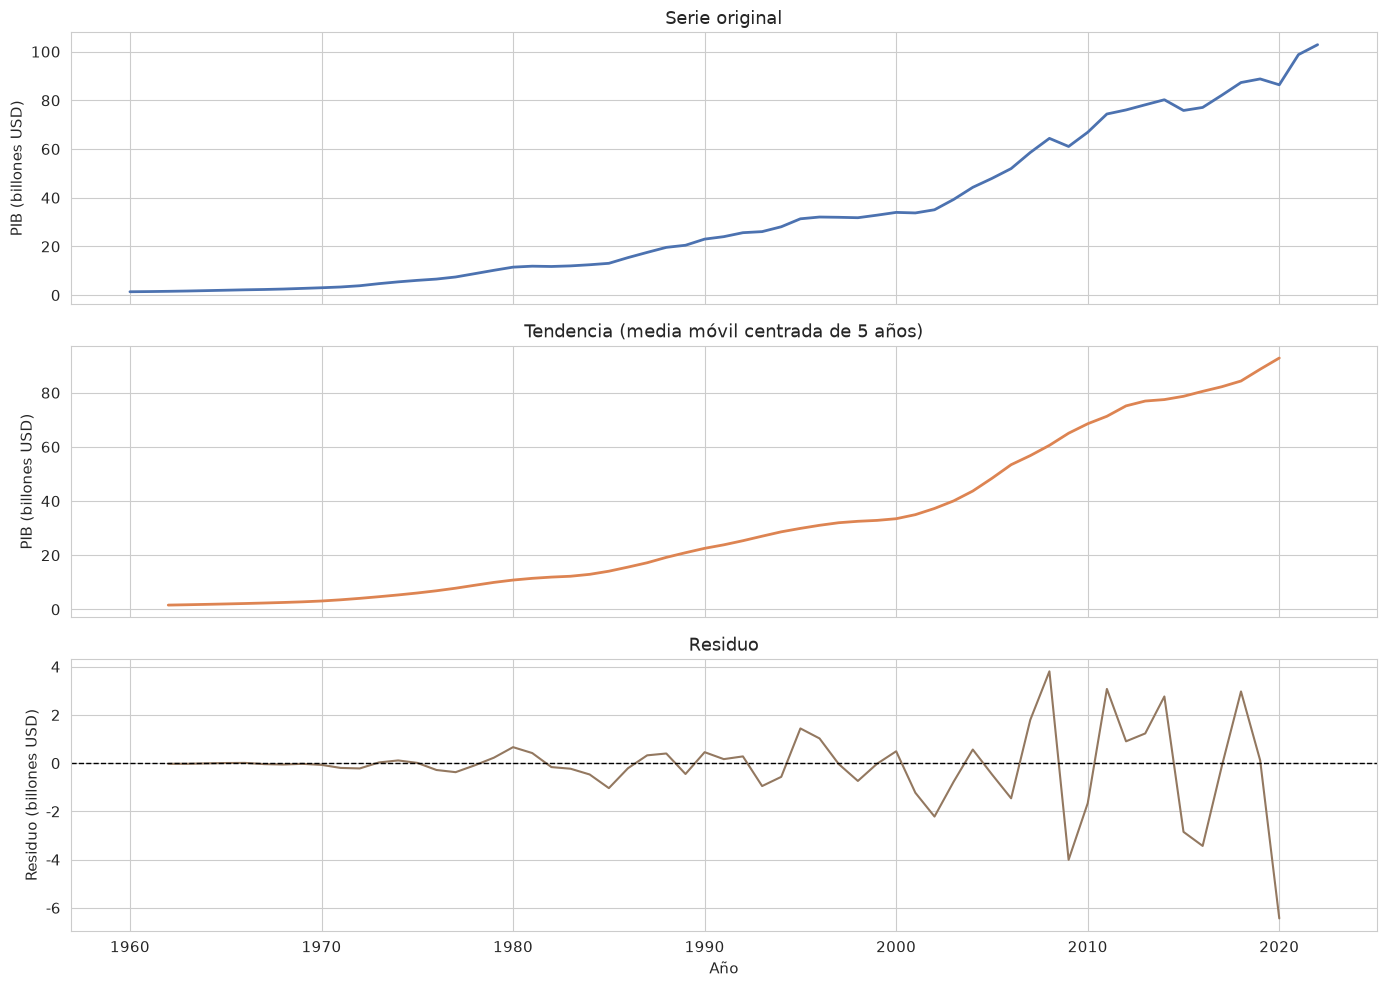

In [25]:

tendencia = serie_mundo.rolling(window=5, center=True).mean()
residuo = serie_mundo - tendencia

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(serie_mundo.index, serie_mundo.values, color="#4c72b0", linewidth=2)
axes[0].set_title("Serie original")
eje_billones(axes[0], "PIB (billones USD)")

axes[1].plot(tendencia.index, tendencia.values, color="#dd8452", linewidth=2)
axes[1].set_title("Tendencia (media móvil centrada de 5 años)")
eje_billones(axes[1], "PIB (billones USD)")

axes[2].plot(residuo.index, residuo.values, color="#937860", linewidth=1.5)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Residuo")
axes[2].set_xlabel("Año")
eje_billones(axes[2], "Residuo (billones USD)")

plt.tight_layout()
plt.show()

## P2. Las economías más grandes y cómo cambió el ranking

In [26]:
top10_2022 = (
    df_largo[df_largo["Anio"] == 2022]
    .nlargest(10, "PIB")[["Country Name", "Region", "IncomeGroup", "PIB"]]
    .reset_index(drop=True)
)
top10_2022["PIB (billones USD)"] = (top10_2022["PIB"] / 1e12).round(2)
top10_2022.drop(columns="PIB")

,Country Name,Region,IncomeGroup,PIB (billones USD)
0,United States,North America,High income,26.05
1,China,East Asia & Pacific,Upper middle income,18.32
2,Japan,East Asia & Pacific,High income,4.45
3,Germany,Europe & Central Asia,High income,4.20
4,India,South Asia,Lower middle income,3.25
5,United Kingdom,Europe & Central Asia,High income,3.18
6,France,Europe & Central Asia,High income,2.79
7,Russian Federation,Europe & Central Asia,High income,2.29
8,Canada,North America,High income,2.20
9,Italy,Europe & Central Asia,High income,2.10


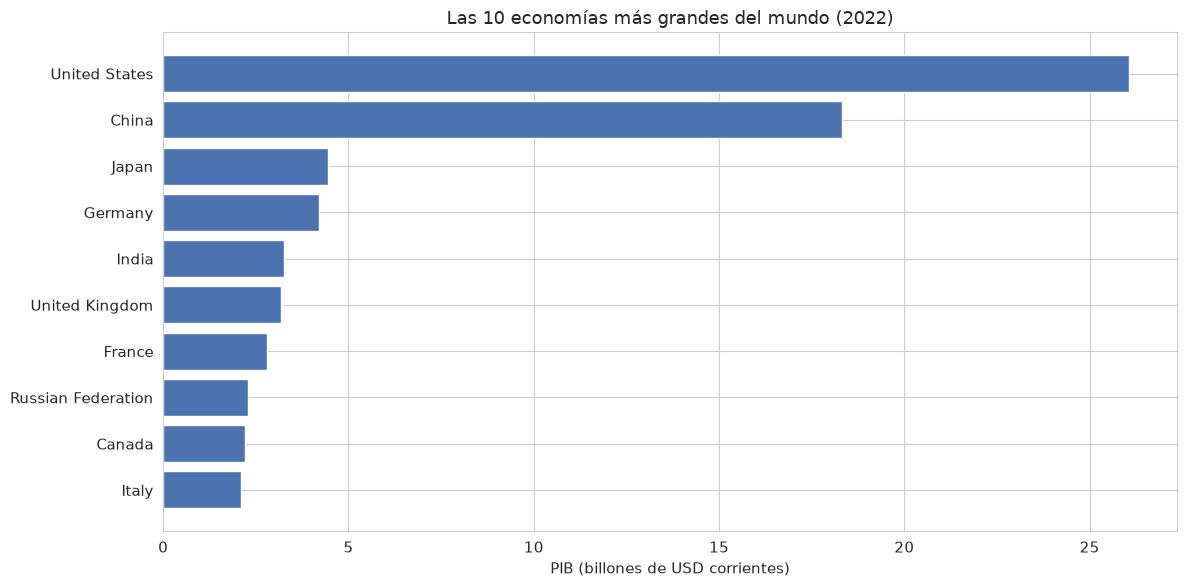

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))
orden = top10_2022.sort_values("PIB")
ax.barh(orden["Country Name"], orden["PIB"], color="#4c72b0")
ax.set_title("Las 10 economías más grandes del mundo (2022)")
ax.set_xlabel("PIB (billones de USD corrientes)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(formato_billones))
plt.tight_layout()
plt.show()

In [28]:
# Cómo cambió el ranking a lo largo del tiempo
for anio in [1960, 1980, 2000, 2022]:
    top5 = df_largo[df_largo["Anio"] == anio].nlargest(5, "PIB")["Country Name"].tolist()
    print(f"{anio}: " + " | ".join(top5))

1960: United States | Germany | United Kingdom | France | China
1980: United States | Japan | Germany | France | United Kingdom
2000: United States | Japan | Germany | United Kingdom | France
2022: United States | China | Japan | Germany | India


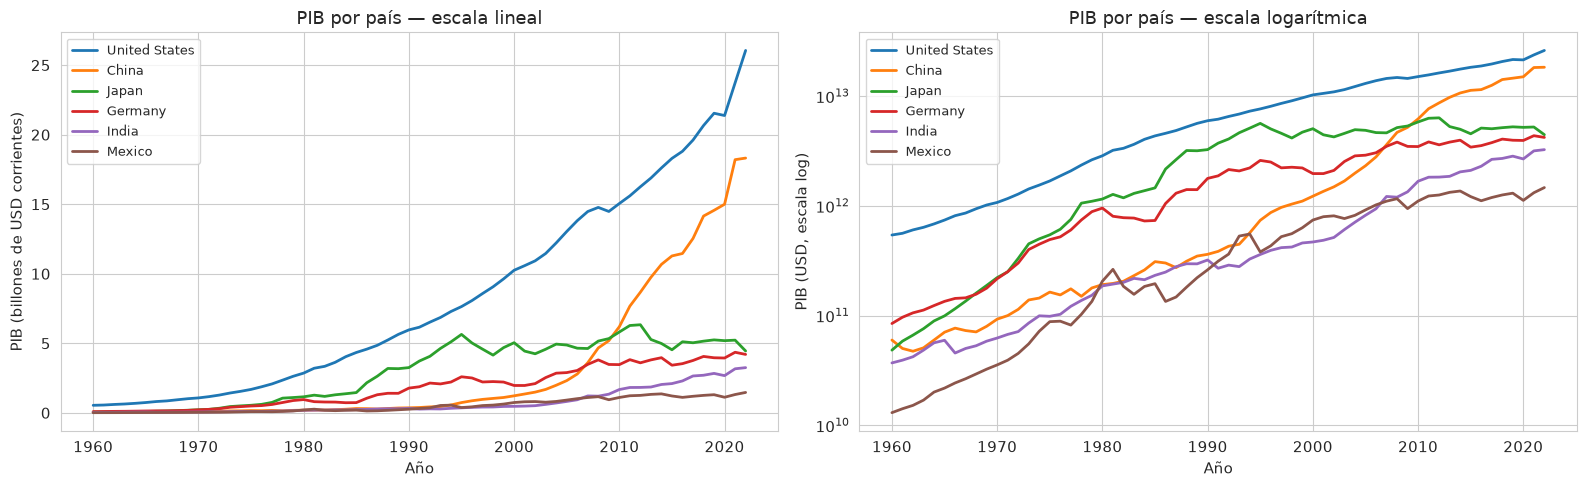

In [29]:
# Series de tiempo de las principales economías
seleccion = ["United States", "China", "Japan", "Germany", "India", "Mexico"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for pais in seleccion:
    axes[0].plot(df_ts.index, df_ts[pais], label=pais, linewidth=2)
    axes[1].plot(df_ts.index, df_ts[pais], label=pais, linewidth=2)

axes[0].set_title("PIB por país — escala lineal")
axes[0].set_xlabel("Año")
eje_billones(axes[0])
axes[0].legend(fontsize=9)

axes[1].set_yscale("log")
axes[1].set_title("PIB por país — escala logarítmica")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("PIB (USD, escala log)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## P3. Comportamiento por región

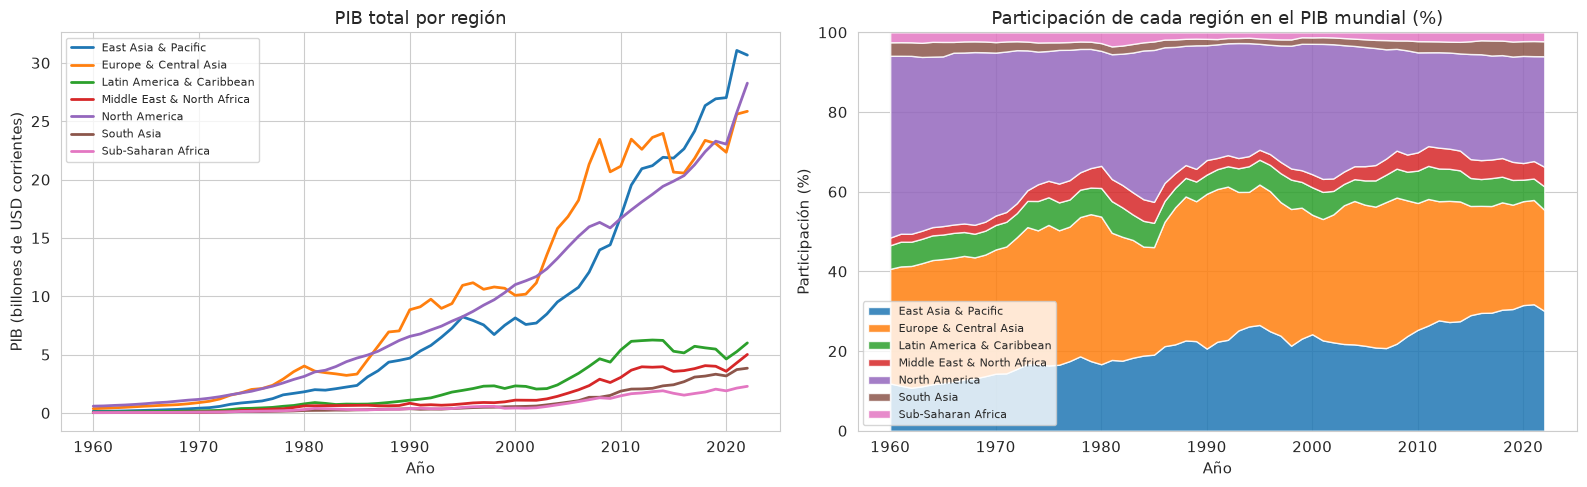

In [30]:
pib_region = df_largo.groupby(["Anio", "Region"])["PIB"].sum().unstack()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Montos absolutos
for region in pib_region.columns:
    axes[0].plot(pib_region.index, pib_region[region], linewidth=2, label=region)
axes[0].set_title("PIB total por región")
axes[0].set_xlabel("Año")
eje_billones(axes[0])
axes[0].legend(fontsize=8)

# Participación porcentual
participacion = pib_region.div(pib_region.sum(axis=1), axis=0) * 100
axes[1].stackplot(
    participacion.index,
    [participacion[c] for c in participacion.columns],
    labels=participacion.columns,
    alpha=0.85,
)
axes[1].set_title("Participación de cada región en el PIB mundial (%)")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Participación (%)")
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.show()

In [31]:
# Comparación explícita de participación: 1960 vs 2022
comparativo = pd.DataFrame({
    "1960 (%)": participacion.loc[1960].round(1),
    "2022 (%)": participacion.loc[2022].round(1),
})
comparativo["Cambio"] = (comparativo["2022 (%)"] - comparativo["1960 (%)"]).round(1)
comparativo.sort_values("Cambio", ascending=False)

,1960 (%),2022 (%),Cambio
Region,,,
East Asia & Pacific,11.9,30.1,18.2
Middle East & North Africa,1.9,4.9,3.0
South Asia,3.4,3.8,0.4
Latin America & Caribbean,5.9,5.9,0.0
Sub-Saharan Africa,2.5,2.2,-0.3
Europe & Central Asia,28.8,25.4,-3.4
North America,45.6,27.7,-17.9


## P4. Comportamiento por nivel de ingreso

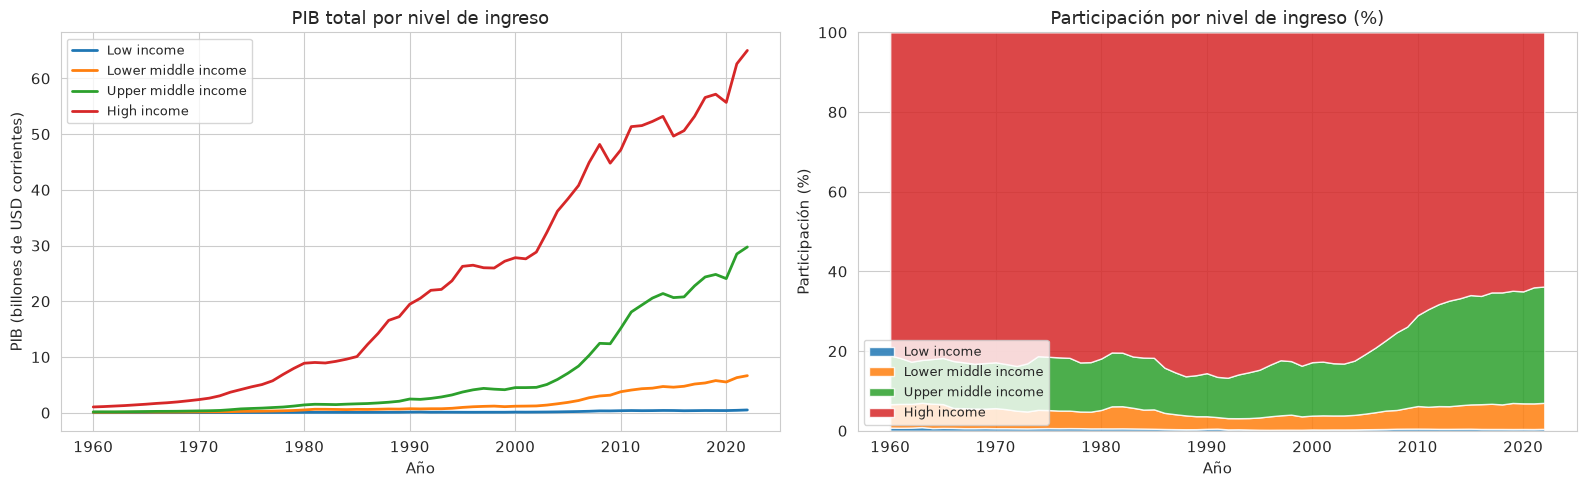

In [32]:
pib_ingreso = df_largo.groupby(["Anio", "IncomeGroup"])["PIB"].sum().unstack()

# Se ordenan los niveles de menor a mayor ingreso
orden_ingreso = ["Low income", "Lower middle income", "Upper middle income", "High income"]
pib_ingreso = pib_ingreso[[c for c in orden_ingreso if c in pib_ingreso.columns]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for nivel in pib_ingreso.columns:
    axes[0].plot(pib_ingreso.index, pib_ingreso[nivel], linewidth=2, label=nivel)
axes[0].set_title("PIB total por nivel de ingreso")
axes[0].set_xlabel("Año")
eje_billones(axes[0])
axes[0].legend(fontsize=9)

part_ingreso = pib_ingreso.div(pib_ingreso.sum(axis=1), axis=0) * 100
axes[1].stackplot(
    part_ingreso.index,
    [part_ingreso[c] for c in part_ingreso.columns],
    labels=part_ingreso.columns,
    alpha=0.85,
)
axes[1].set_title("Participación por nivel de ingreso (%)")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Participación (%)")
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=9, loc="lower left")

plt.tight_layout()
plt.show()

In [33]:
print("Número de países por nivel de ingreso:")
print(paises["IncomeGroup"].value_counts().to_string())
print()
print("Participación en el PIB mundial (%):")
print(pd.DataFrame({
    "1960": part_ingreso.loc[1960].round(1),
    "2022": part_ingreso.loc[2022].round(1),
}).to_string())

Número de países por nivel de ingreso:
IncomeGroup
High income            86
Upper middle income    59
Lower middle income    47
Low income             25

Participación en el PIB mundial (%):
                     1960  2022
IncomeGroup                    
Low income            0.8   0.5
Lower middle income   5.9   6.5
Upper middle income  12.3  29.2
High income          81.1  63.8


## P5. Tasa de crecimiento anual: ¿dónde están las crisis?

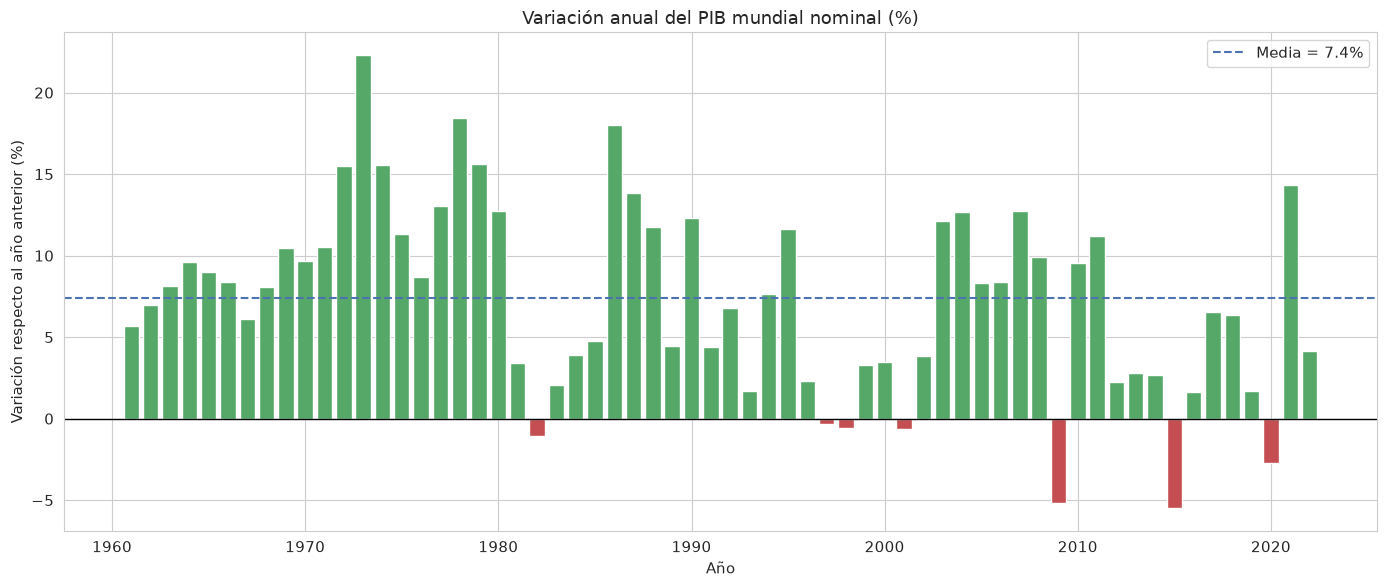

Años con caída del PIB mundial nominal:
      Variación %
Anio             
2015        -5.49
2009        -5.17
2020        -2.71
1982        -1.06
2001        -0.64
1998        -0.54
1997        -0.34


In [34]:
# La tasa de crecimiento es la primera diferencia porcentual de la serie
crecimiento_mundo = serie_mundo.pct_change() * 100

fig, ax = plt.subplots(figsize=(14, 6))
colores = ["#c44e52" if v < 0 else "#55a868" for v in crecimiento_mundo.fillna(0)]
ax.bar(crecimiento_mundo.index.year, crecimiento_mundo.values, color=colores)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(crecimiento_mundo.mean(), color="#4c72b0", linestyle="--",
           label=f"Media = {crecimiento_mundo.mean():.1f}%")
ax.set_title("Variación anual del PIB mundial nominal (%)")
ax.set_xlabel("Año")
ax.set_ylabel("Variación respecto al año anterior (%)")
ax.legend()
plt.tight_layout()
plt.show()

print("Años con caída del PIB mundial nominal:")
caidas = crecimiento_mundo[crecimiento_mundo < 0].sort_values()
print(caidas.to_frame("Variación %").assign(
    Anio=lambda d: d.index.year).set_index("Anio").round(2).to_string())

## P6. Análisis de estacionariedad


In [ ]:

def prueba_adf(serie, alpha=0.05):
    """Prueba de Dickey-Fuller aumentada. H0: la serie NO es estacionaria."""
    resultado = adfuller(serie.dropna(), autolag="AIC")
    return {
        "estadistico": resultado[0],
        "p_value": resultado[1],
        "n_lags": resultado[2],
        "n_obs": resultado[3],
        "valores_criticos": resultado[4],
        "conclusion": "ESTACIONARIA" if resultado[1] < alpha else "NO ESTACIONARIA",
    }


def prueba_kpss(serie, regression="c", alpha=0.05):
    """Prueba KPSS. H0: la serie SÍ es estacionaria."""
    resultado = kpss(serie.dropna(), regression=regression, nlags="auto")
    return {
        "estadistico": resultado[0],
        "p_value": resultado[1],
        "n_lags": resultado[2],
        "valores_criticos": resultado[3],
        "conclusion": "NO ESTACIONARIA" if resultado[1] < alpha else "ESTACIONARIA",
    }


def analizar_estacionariedad(serie, nombre):
    """Corre ADF y KPSS sobre la misma serie y combina las conclusiones."""
    print("=" * 62)
    print(f"SERIE: {nombre}")
    print("=" * 62)

    adf = prueba_adf(serie)
    kps = prueba_kpss(serie)

    print(f"ADF   -> estadístico = {adf['estadistico']:8.4f}   "
          f"p-value = {adf['p_value']:.4f}   rezagos = {adf['n_lags']}")
    print(f"         valores críticos: " +
          ", ".join(f"{k}: {v:.3f}" for k, v in adf["valores_criticos"].items()))
    print(f"         conclusión ADF : {adf['conclusion']}")
    print()
    print(f"KPSS  -> estadístico = {kps['estadistico']:8.4f}   "
          f"p-value = {kps['p_value']:.4f}   rezagos = {kps['n_lags']}")
    print(f"         conclusión KPSS: {kps['conclusion']}")
    print()

    # Interpretación combinada de las dos pruebas
    if adf["conclusion"] == "ESTACIONARIA" and kps["conclusion"] == "ESTACIONARIA":
        veredicto = "ESTACIONARIA — ambas pruebas coinciden"
    elif adf["conclusion"] == "NO ESTACIONARIA" and kps["conclusion"] == "NO ESTACIONARIA":
        veredicto = "NO ESTACIONARIA — ambas pruebas coinciden"
    elif adf["conclusion"] == "NO ESTACIONARIA" and kps["conclusion"] == "ESTACIONARIA":
        veredicto = "Resultado mixto: posible estacionariedad alrededor de una tendencia"
    else:
        veredicto = "Resultado mixto: la serie puede requerir más transformaciones"

    print(f"{veredicto}")
    print()
    return {"serie": nombre, "adf_p": adf["p_value"], "kpss_p": kps["p_value"],
            "veredicto": veredicto}

In [36]:

r1 = analizar_estacionariedad(serie_mundo, "PIB mundial (nivel, USD corrientes)")

SERIE: PIB mundial (nivel, USD corrientes)
ADF   -> estadístico =   3.6083   p-value = 1.0000   rezagos = 9
         valores críticos: 1%: -3.560, 5%: -2.918, 10%: -2.597
         conclusión ADF : NO ESTACIONARIA

KPSS  -> estadístico =   1.0761   p-value = 0.0100   rezagos = 5
         conclusión KPSS: NO ESTACIONARIA

>>> VEREDICTO: NO ESTACIONARIA — ambas pruebas coinciden



In [37]:

log_mundo = np.log(serie_mundo)
r2 = analizar_estacionariedad(log_mundo, "log(PIB mundial)")

SERIE: log(PIB mundial)
ADF   -> estadístico =  -2.4406   p-value = 0.1306   rezagos = 1
         valores críticos: 1%: -3.542, 5%: -2.910, 10%: -2.593
         conclusión ADF : NO ESTACIONARIA

KPSS  -> estadístico =   1.1214   p-value = 0.0100   rezagos = 5
         conclusión KPSS: NO ESTACIONARIA

>>> VEREDICTO: NO ESTACIONARIA — ambas pruebas coinciden



In [38]:

dlog_mundo = log_mundo.diff()
r3 = analizar_estacionariedad(dlog_mundo, "Primera diferencia de log(PIB mundial)")

SERIE: Primera diferencia de log(PIB mundial)
ADF   -> estadístico =  -4.6633   p-value = 0.0001   rezagos = 0
         valores críticos: 1%: -3.542, 5%: -2.910, 10%: -2.593
         conclusión ADF : ESTACIONARIA

KPSS  -> estadístico =   0.5759   p-value = 0.0248   rezagos = 3
         conclusión KPSS: NO ESTACIONARIA

>>> VEREDICTO: Resultado mixto: la serie puede requerir más transformaciones



In [39]:
r3_ct = prueba_kpss(dlog_mundo, regression="ct")

print("KPSS sobre Δlog(PIB) permitiendo una tendencia (regression='ct')")
print("-" * 62)
print(f"estadístico = {r3_ct['estadistico']:.4f}   p-value = {r3_ct['p_value']:.4f}")
print(f"conclusión  : {r3_ct['conclusion']}")
print()
print("Comparación de los dos KPSS sobre la MISMA serie:")
print(f"  regression='c'  (alrededor de una constante) -> p = {r3['kpss_p']:.4f}  NO estacionaria")
print(f"  regression='ct' (alrededor de una tendencia) -> p = {r3_ct['p_value']:.4f}  estacionaria")

KPSS sobre Δlog(PIB) permitiendo una tendencia (regression='ct')
--------------------------------------------------------------
estadístico = 0.0594   p-value = 0.1000
conclusión  : ESTACIONARIA

Comparación de los dos KPSS sobre la MISMA serie:
  regression='c'  (alrededor de una constante) -> p = 0.0248  NO estacionaria
  regression='ct' (alrededor de una tendencia) -> p = 0.1000  estacionaria


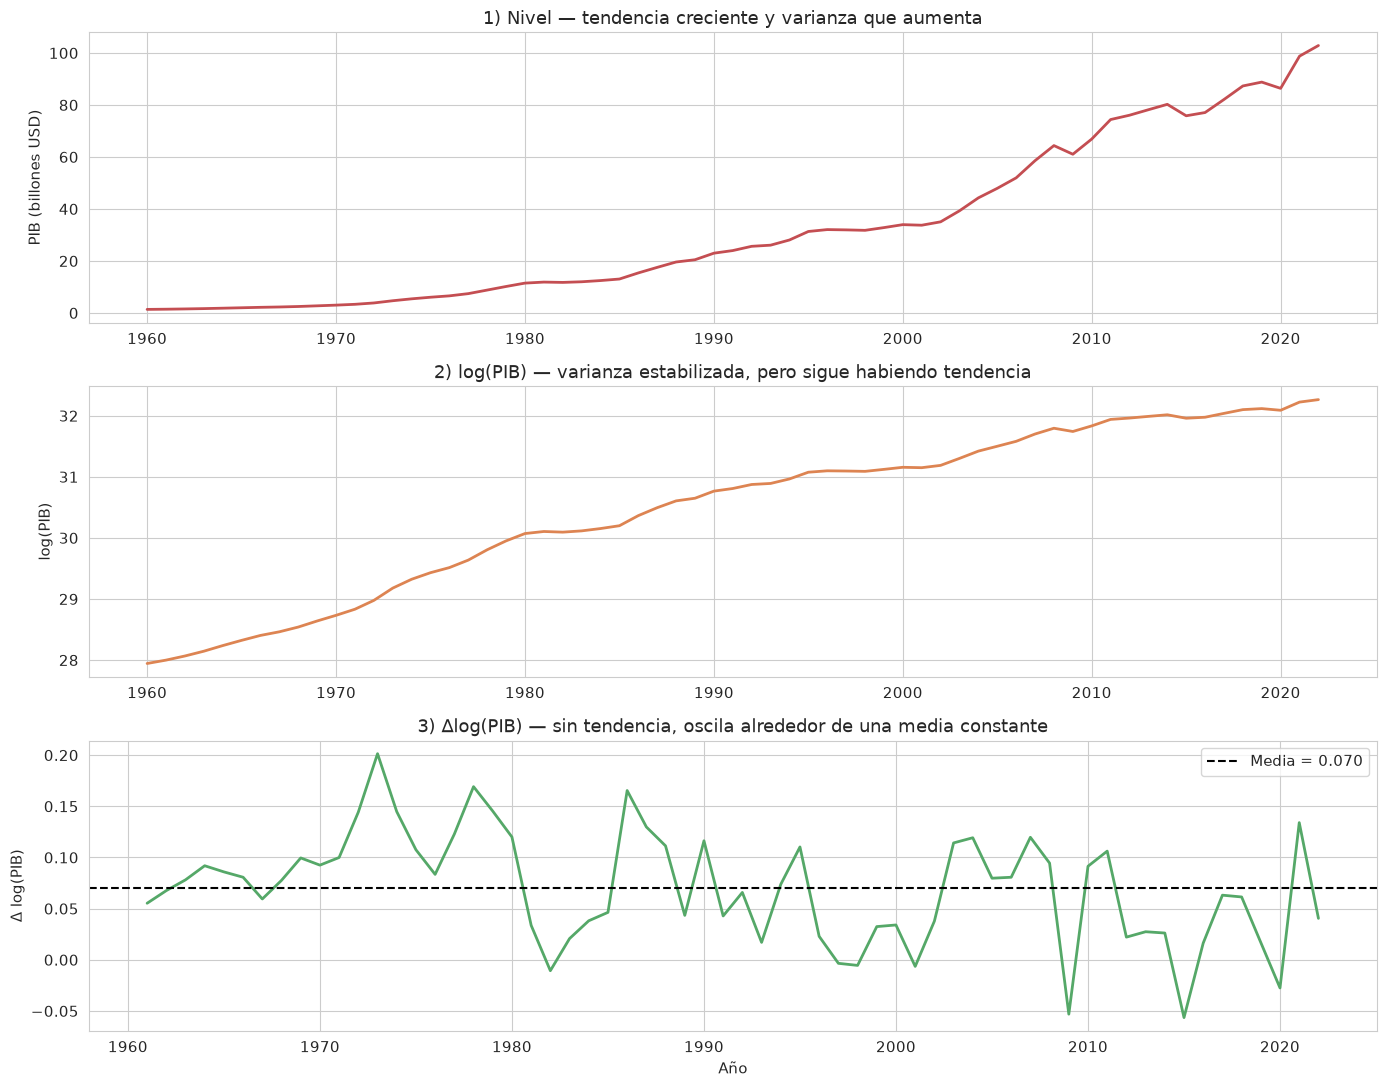

In [40]:
# Comparación visual de las tres versiones de la serie
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

axes[0].plot(serie_mundo.index, serie_mundo.values, color="#c44e52", linewidth=2)
axes[0].set_title("1) Nivel — tendencia creciente y varianza que aumenta")
eje_billones(axes[0], "PIB (billones USD)")

axes[1].plot(log_mundo.index, log_mundo.values, color="#dd8452", linewidth=2)
axes[1].set_title("2) log(PIB) — varianza estabilizada, pero sigue habiendo tendencia")
axes[1].set_ylabel("log(PIB)")

axes[2].plot(dlog_mundo.index, dlog_mundo.values, color="#55a868", linewidth=2)
axes[2].axhline(dlog_mundo.mean(), color="black", linestyle="--",
                label=f"Media = {dlog_mundo.mean():.3f}")
axes[2].set_title("3) Δlog(PIB) — sin tendencia, oscila alrededor de una media constante")
axes[2].set_xlabel("Año")
axes[2].set_ylabel("Δ log(PIB)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [41]:
# Resumen de las pruebas
resumen = pd.DataFrame([r1, r2, r3])
resumen[["adf_p", "kpss_p"]] = resumen[["adf_p", "kpss_p"]].round(4)
resumen

,serie,adf_p,kpss_p,veredicto
0,"PIB mundial (nivel, USD corrientes)",1.0000,0.0100,NO ESTACIONARIA — ambas pruebas coinciden
1,log(PIB mundial),0.1306,0.0100,NO ESTACIONARIA — ambas pruebas coinciden
2,Primera diferencia de log(PIB mundial),0.0001,0.0248,Resultado mixto: la serie puede requerir más t...


### Verificación gráfica: media y desviación móviles


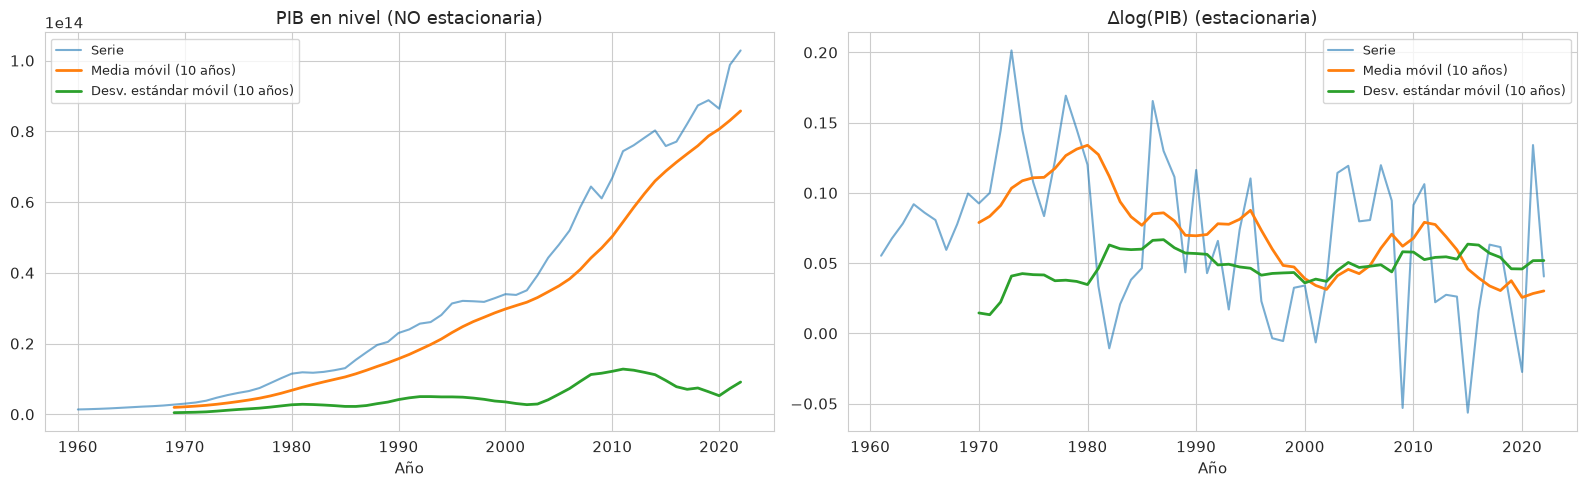

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, serie, titulo in zip(
    axes,
    [serie_mundo, dlog_mundo],
    ["PIB en nivel (NO estacionaria)", "Δlog(PIB) (estacionaria)"],
):
    media_movil = serie.rolling(window=10).mean()
    desv_movil = serie.rolling(window=10).std()

    ax.plot(serie.index, serie.values, label="Serie", alpha=0.6)
    ax.plot(media_movil.index, media_movil.values, label="Media móvil (10 años)", linewidth=2)
    ax.plot(desv_movil.index, desv_movil.values, label="Desv. estándar móvil (10 años)",
            linewidth=2)
    ax.set_title(titulo)
    ax.set_xlabel("Año")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

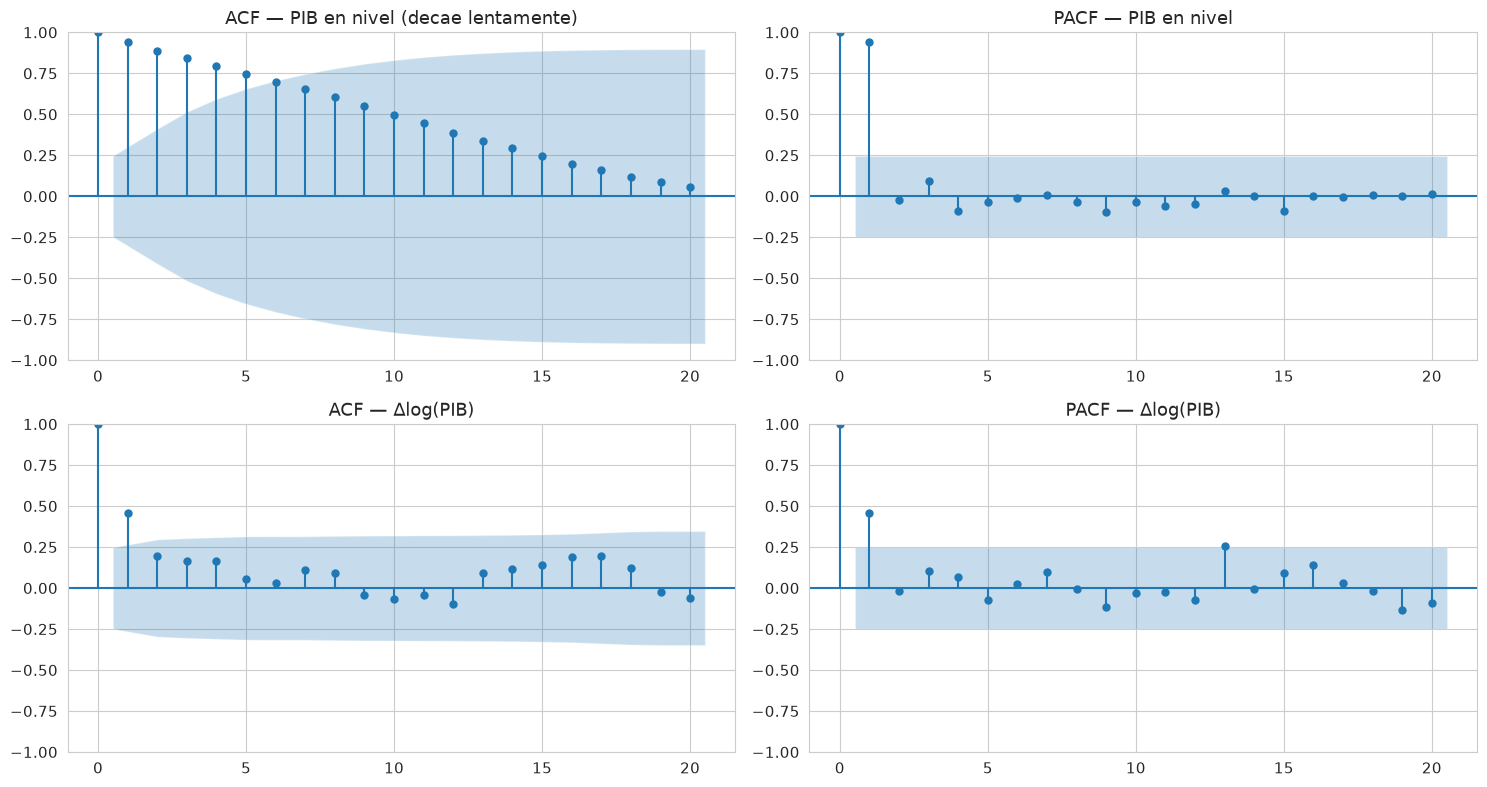

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

plot_acf(serie_mundo.dropna(), ax=axes[0, 0], lags=20, alpha=0.05)
axes[0, 0].set_title("ACF — PIB en nivel (decae lentamente)")

plot_pacf(serie_mundo.dropna(), ax=axes[0, 1], lags=20, alpha=0.05, method="ywm")
axes[0, 1].set_title("PACF — PIB en nivel")

plot_acf(dlog_mundo.dropna(), ax=axes[1, 0], lags=20, alpha=0.05)
axes[1, 0].set_title("ACF — Δlog(PIB)")

plot_pacf(dlog_mundo.dropna(), ax=axes[1, 1], lags=20, alpha=0.05, method="ywm")
axes[1, 1].set_title("PACF — Δlog(PIB)")

plt.tight_layout()
plt.show()


# 5. Conclusiones

**Sobre los datos**

1. El set de datos del Banco Mundial viene en **formato ancho** (un año por columna) y hubo que
   transponerlo para tratarlo como serie de tiempo.
2. La tabla mezcla **países y agregados** (World, European Union, High income, etc.). Separarlos
   usando la columna `Region` de los metadatos fue indispensable para no duplicar montos.
3. Los faltantes se concentran en las décadas de 1960 y 1970 y son tramos completos al inicio de
   cada serie, no huecos aislados. Se dejaron como `NaN` en lugar de imputarlos, para no
   distorsionar la tendencia.

**Sobre el comportamiento histórico**

4. El PIB mundial creció de forma **aproximadamente exponencial** entre 1960 y 2022. En escala
   logarítmica la serie es casi una recta, señal de crecimiento multiplicativo.
5. La serie tiene **tendencia creciente y varianza que aumenta con el nivel**; ambos son síntomas
   clásicos de no estacionariedad.
6. Las **caídas del PIB nominal** coinciden con crisis conocidas (inicios de los ochenta, 2009 y
   2020), pero la mayor de todas es la de **2015**, provocada por la apreciación del dólar y no
   por una caída de la producción. Los ciclos económicos son irregulares, por lo que **no**
   constituyen estacionalidad.
7. Al ser una serie **anual**, no existe componente estacional: la estacionalidad requiere
   observaciones dentro de un mismo periodo (meses, trimestres). La descomposición se limita a
   tendencia y residuo.
